<a href="https://colab.research.google.com/github/Ram6023/ML-Practice/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [59]:
data = pd.read_csv('optimized_waste_management_data.csv')

In [60]:
data =data .fillna(method='ffill')

/tmp/ipykernel_291/3253247370.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data =data .fillna(method='ffill')


In [61]:
waste_data=data[['waste_volume']]

In [62]:
scaler_object = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler_object.fit_transform(waste_data)

In [63]:
def create_sequences(data, seq_length):
    x=[]
    y=[]
    for i in range(len(data)-seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(x), np.array(y)

In [64]:
sequence_length=10
X,y=create_sequences(scaled_data,sequence_length)
print(X.shape,y.shape)

(1451, 10, 1) (1451, 1)


In [65]:
split=int(len(X)*0.8)
X_train=X[:split]
X_test=X[split:]
y_train=y[:split]
y_test=y[split:]

In [66]:
model=Sequential()
model.add(SimpleRNN(50,activation='tanh',input_shape=(sequence_length,1)))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [67]:
model.compile(optimizer='adam', loss='mean_squared_error' )

In [68]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0425 - val_loss: 0.0126
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0102 - val_loss: 0.0113
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0107 - val_loss: 0.0135
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0096 - val_loss: 0.0115
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0089 - val_loss: 0.0145
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0091 - val_loss: 0.0113
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0112 - val_loss: 0.0183
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0099 - val_loss: 0.0116
Epoch 9/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0102 - val_loss: 0.0118
Epoch 10/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0098 - val_loss: 0.0122


In [70]:
loss = model. evaluate(X_test, y_test)
print('Test Loss:', loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0084 
Test Loss: 0.009321214631199837


In [71]:
predictions = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [72]:
predictions = scaler_object.inverse_transform(predictions)
y_test_actual = scaler_object.inverse_transform(y_test)

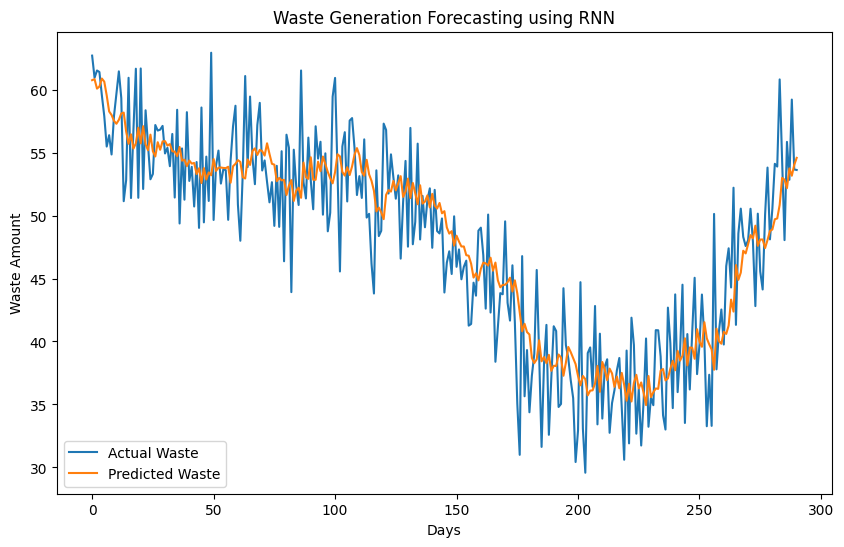

In [73]:
plt.figure(figsize=(10,6))

plt.plot(y_test_actual, label='Actual Waste')
plt.plot(predictions, label='Predicted Waste')

plt.title('Waste Generation Forecasting using RNN')
plt.xlabel('Days')
plt.ylabel('Waste Amount')
plt.legend()
plt.show()